In [1]:
#import required python classes and packages
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2Model
import os
from sklearn.model_selection import train_test_split
import re
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
#function to generate time series based sequences from input dataset
def prepare_data(features, label, sequence_length):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(features)
    scaler1 = MinMaxScaler()
    label_data = scaler1.fit_transform(label)
    X, y = [], []
    for i in range(len(scaled_data) - sequence_length):
        X.append(scaled_data[i:i + sequence_length])
        y.append(label_data[i + sequence_length]) 
    return np.array(X), np.array(y), scaler, scaler1

In [3]:
#class to convert sequence numpy to time series data
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
#function to generate GPT features from stock news data to extract sentiments and other events
# --- GPT-2 based feature extraction (Example of how to use GPT) ---
def get_gpt_features(text_data):
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    model = GPT2Model.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token #prevent warnings
    inputs = tokenizer(text_data, return_tensors='pt', padding=True, truncation=True, max_length=32)
    outputs = model(**inputs)
    last_hidden_states = outputs.last_hidden_state
    return last_hidden_states.mean(dim=1).detach().numpy() #Average the token embeddings

In [5]:
# hybrid Transformer model by combining GPT and Time series based features
class TimeSeriesTransformer(nn.Module):
    """Time-series Transformer model."""
    def __init__(self, input_size, sequence_length, num_layers, num_heads, d_model, d_ff, dropout):
        super(TimeSeriesTransformer, self).__init__()
        self.input_size = input_size
        self.sequence_length = sequence_length
        self.d_model = d_model

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = self._get_positional_encoding(sequence_length, d_model)
        self.transformer_layers = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, num_heads, d_ff, dropout),
            num_layers
        )
        self.output_projection = nn.Linear(d_model, 1) # Predict one value

    def _get_positional_encoding(self, seq_len, d_model):
        """Generates positional encodings."""
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)

    def forward(self, x):
        x = self.input_projection(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, d_model)
        x = x + self.positional_encoding.to(x.device)
        x = self.transformer_layers(x)
        x = x.mean(dim=0)  # Average pooling over sequence length
        x = self.output_projection(x)
        return x.squeeze()

In [6]:
#load dataset with stock prices and news data
dataset = pd.read_csv("Dataset/test.csv", nrows=200)
dataset

,Date,Top1,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,Georgia downs two Russian warplanes as countri...,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1,2008-08-11,Why wont America and Nato help us? If they won...,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2,2008-08-12,Remember that adorable 9-year-old who sang at ...,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
3,2008-08-13,U.S. refuses Israel weapons to attack Iran: r...,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
4,2008-08-14,All the experts admit that we should legalise ...,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...,...
195,2009-05-19,The Belgian bodybuilding championship has been...,8502.480469,8538.009766,8463.540039,8474.849609,277710000,8474.849609
196,2009-05-20,Endemic rape and abuse of Irish children in Ca...,8471.820312,8591.929688,8405.469727,8422.040039,468640000,8422.040039
197,2009-05-21,The Nigerian military has been accused of kill...,8416.070312,8416.150391,8221.009766,8292.129883,302280000,8292.129883
198,2009-05-22,Tiananmen anniversary unimportant to Chinese y...,8292.209961,8364.139648,8257.169922,8277.320312,244190000,8277.320312


In [7]:
#now combine GPT news features with stock data
if os.path.exists("model/news.npy") == False:
    news_features = get_gpt_features(dataset['Top1'].tolist()) #Get GPT features from news.
    np.save("model/news", news_features)
else:
    news_features = np.load("model/news.npy")
dataset.drop(['Date','Top1'], axis = 1,inplace=True)
dataset = dataset.values
features = dataset[:,0:4]
label = dataset[:,5:6]
num_samples = dataset.shape[0]
sequence_length = 8
hybrid_features = np.concatenate((features,news_features), axis=1)
print("Stock & GPT Features = "+str(hybrid_features))

Stock & GPT Features = [[ 1.14320898e+04  1.17599600e+04  1.13880400e+04 ... -1.41395330e-01
  -7.83495232e-02  4.10106033e-03]
 [ 1.17296699e+04  1.18671104e+04  1.16755303e+04 ... -9.91968811e-02
   1.07712708e-01  1.48205915e-02]
 [ 1.17817002e+04  1.17823496e+04  1.16015195e+04 ... -3.97140682e-02
  -1.93846285e-01 -1.02183316e-02]
 ...
 [ 8.41607031e+03  8.41615039e+03  8.22100977e+03 ... -2.65066512e-02
  -1.75343573e-01 -1.00388989e-01]
 [ 8.29220996e+03  8.36413965e+03  8.25716992e+03 ... -6.05912730e-02
  -2.38173962e-01 -5.34534715e-02]
 [ 8.27732031e+03  8.49570996e+03  8.22690039e+03 ...  4.08215597e-02
  -2.45531708e-01 -1.16307735e-01]]


In [8]:
#function to calculate score using true and predicted stock
def getScore(model, sc):
    y_test1 = sc.inverse_transform(y_test).ravel()
    y_pred = []
    for j in range(len(X_test)):
        index = X_test[j]
        temp = []
        temp.append(index)
        index = np.asarray(temp)
        last_sequence = torch.tensor(index, dtype=torch.float32)
        predicted_scaled = model(last_sequence).detach().numpy()
        predicted_scaled = predicted_scaled.reshape(-1, 1)
        predicted_scaled = sc.inverse_transform(predicted_scaled)
        predicted_scaled = predicted_scaled.ravel().mean()    
        y_pred.append(predicted_scaled)
    mse_error = np.sqrt(mean_squared_error(y_test, y_pred))
    square_error = r2_score(y_test1, y_pred)
    return y_test1, y_pred, mse_error, square_error

Hybrid Transformer RMSE = 8772.88008767609
Hybrid Transformer R2 Score = 0.2464748871727248


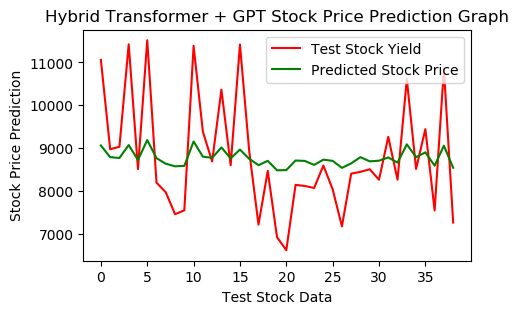

In [9]:
#processs and split hybrid features as training and testing and then trained wwith Transformer + GPT model
X, y, scaler, scaler1 = prepare_data(hybrid_features, label, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
dataset = TimeSeriesDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
# Time-Series Transformer parameters
input_size = X.shape[2]
num_layers = 2
num_heads = 2
d_model = 64
d_ff = 256
dropout = 0.3
gpt_trans_model = TimeSeriesTransformer(input_size, sequence_length, num_layers, num_heads, d_model, d_ff, dropout)
criterion = nn.MSELoss()
optimizer = optim.Adam(gpt_trans_model.parameters(), lr=0.001)
best_loss = 10000
if os.path.exists("model/gpt.pt") == False:
    # Training loop
    num_epochs = 1000
    for epoch in range(num_epochs):#training model for given number of epochs
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = gpt_trans_model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(gpt_trans_model.state_dict(), "model/gpt.pt")
            print("best saved : "+str(best_loss))    
else:
    gpt_trans_model.load_state_dict(torch.load("model/gpt.pt"))
    gpt_trans_model.eval()
y_true, y_pred, transformer_rmse, transformer_r2_score = getScore(gpt_trans_model, scaler1)  
print("Hybrid Transformer RMSE = "+str(transformer_rmse))
print("Hybrid Transformer R2 Score = "+str(transformer_r2_score))
plt.figure(figsize=(5,3))
plt.plot(y_true, color = 'red', label = 'Test Stock Yield')
plt.plot(y_pred, color = 'green', label = 'Predicted Stock Price')
plt.title('Hybrid Transformer + GPT Stock Price Prediction Graph')
plt.xlabel('Test Stock Data')
plt.ylabel('Stock Price Prediction')
plt.legend()
plt.show()    

In [10]:
#defining QINN model
# --- QINN Layer (Simplified Example) ---
class QINNLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(QINNLayer, self).__init__()
        self.weights = nn.Parameter(torch.rand(input_size, output_size))
        # Simplified "quantum-inspired" activation function
        self.activation = lambda x: torch.sin(x)

    def forward(self, x):
        return self.activation(torch.matmul(x, self.weights))

# --- QINN Model ---
class QINN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(QINN, self).__init__()
        self.qinn1 = QINNLayer(input_size, hidden_size)
        self.qinn2 = QINNLayer(hidden_size, output_size)
        self.output_layer = nn.Linear(output_size, 1)

    def forward(self, x):
        x = self.qinn1(x)
        x = self.qinn2(x)
        x = self.output_layer(x)
        return x.squeeze()


QINN RMSE = 8675.57457417681
QINN R2 Score = 0.7714253011616251


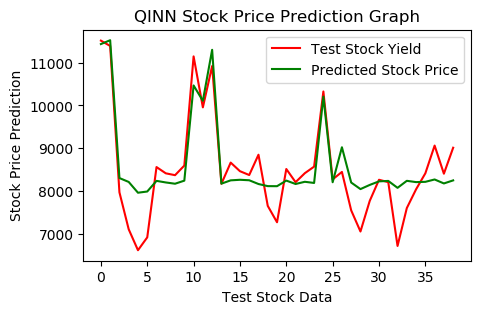

In [11]:
#processs and split hybrid features as training and testing and then trained wwith Transformer + GPT model
X1, y1, scaler2, scaler3 = prepare_data(features, label, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size = 0.2)
dataset = TimeSeriesDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
#training QINN model
# QINN parameters
input_size = X1.shape[2]
hidden_size = 64
output_size = 32
qinn_model = QINN(input_size, hidden_size, output_size)#creating QINN object
criterion = nn.MSELoss()
optimizer = optim.Adam(qinn_model.parameters(), lr=0.001)
best_loss = 10000
if os.path.exists("model/qinn.pt") == False:
    # Training loop
    num_epochs = 1000
    for epoch in range(num_epochs):
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = qinn_model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(qinn_model.state_dict(), "model/qinn.pt")
            print("best saved : "+str(best_loss))    
else:
    qinn_model.load_state_dict(torch.load("model/qinn.pt"))
    qinn_model.eval()
y_true, y_pred, qinn_rmse, qinn_r2_score = getScore(qinn_model, scaler3)  
print("QINN RMSE = "+str(qinn_rmse))
print("QINN R2 Score = "+str(qinn_r2_score))
plt.figure(figsize=(5,3))
plt.plot(y_true, color = 'red', label = 'Test Stock Yield')
plt.plot(y_pred, color = 'green', label = 'Predicted Stock Price')
plt.title('QINN Stock Price Prediction Graph')
plt.xlabel('Test Stock Data')
plt.ylabel('Stock Price Prediction')
plt.legend()
plt.show()        

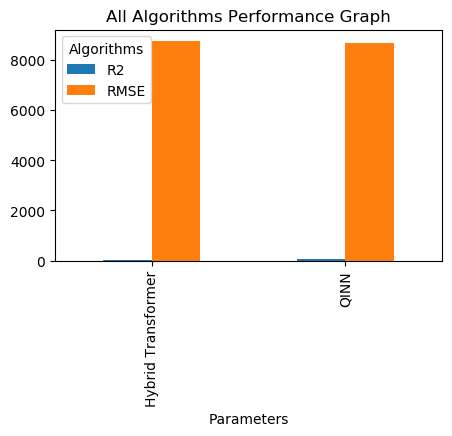

In [12]:
df = pd.DataFrame([['Hybrid Transformer','RMSE',transformer_rmse],['Hybrid Transformer','R2',transformer_r2_score*100],
                   ['QINN','RMSE',qinn_rmse],['QINN','R2',qinn_r2_score*100],      
                    
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(5,3))
plt.title("All Algorithms Performance Graph")
plt.show()